In [ ]:
from google.colab import drive
import h5py
import numpy as np
import os

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Astro Projects/Galaxy morphology/data/Galaxy10_DECals.h5'
local_path = '/content/Galaxy10_DECals.h5'

if not os.path.exists(local_path):
    print("Copying dataset to local VM disk...")
    !cp "{drive_path}" "{local_path}"
    print("Transfer complete.")

print("Loading dataset into RAM safely...")
with h5py.File(local_path, 'r') as f:
    # Load as uint8 (0-255) -> Only consumes ~3.5 GB of RAM!
    images = np.array(f['images'], dtype=np.uint8)
    labels = np.array(f['ans'], dtype=np.int64)

print(f"Loaded successfully!")
print(f"Images Shape: {images.shape} | Data Type: {images.dtype}")
print(f"Memory used by images array: {images.nbytes / (1024**3):.2f} GB")

Mounted at /content/drive
Copying dataset to local VM disk...
Transfer complete.
Loading dataset into RAM safely...
Loaded successfully!
Images Shape: (17736, 256, 256, 3) | Data Type: uint8
Memory used by images array: 3.25 GB


In [ ]:
import tensorflow as tf

model_10 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model/galaxy10_efficientnetb0_phase2_run2.keras')

model_6 = tf.keras.models.load_model('/content/drive/MyDrive/Astro Projects/Galaxy morphology/model-2/galaxy10_efficientnetb0_phase3.keras')


In [ ]:
label_mapping = {
    0: 0,  # Disturbed → Disturbed
    1: 1,  # Merging → Merging
    2: 2,  # Round Smooth → Elliptical
    3: 2,  # In-between Round Smooth → Elliptical
    4: 2,  # Cigar Shaped Smooth → Elliptical
    5: 3,  # Barred Spiral → Barred Spiral
    6: 4,  # Unbarred Tight Spiral → Unbarred Spiral
    7: 4,  # Unbarred Loose Spiral → Unbarred Spiral
    8: 5,  # Edge-on without Bulge → Edge-on
    9: 5   # Edge-on with Bulge → Edge-on
}

y_6class = np.array([label_mapping[label] for label in labels])

class_names = [
    "Disturbed",
    "Merging",
    "Elliptical",
    "Barred Spiral",
    "Unbarred Spiral",
    "Edge-on"
]

In [ ]:
from sklearn.model_selection import train_test_split
indices=np.arange(len(images))

train_idx,val_idx,y_train,y_val=train_test_split(indices,y_6class,test_size=0.2,stratify=y_6class,random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size=32
target_size=(224,224)

In [ ]:
def data_generator(indices,image_array,label_array):

  for idx in indices:
    yield image_array[idx].astype(np.float32),label_array[idx]

In [ ]:
def preprocess(image,label):

  image=tf.image.resize(image,target_size)

  return image,label

In [ ]:

def create_pipeline(indices, is_training=True):
    ds = tf.data.Dataset.from_generator(
        lambda: data_generator(indices, images, y_6class),
        output_signature=(
            tf.TensorSpec(shape=images.shape[1:], dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 1000))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    if is_training:
      ds=ds.repeat()

    ds=ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_dataset = create_pipeline(train_idx, is_training=True)
val_dataset = create_pipeline(val_idx, is_training=False)

In [ ]:
for images_batch, labels_batch in val_dataset.take(1):
    print(images_batch.shape)
    print(labels_batch.shape)
    print(labels_batch[:10].numpy())

(32, 224, 224, 3)
(32,)
[5 2 5 1 4 4 1 1 0 2]


In [ ]:
print(np.unique(y_6class))

[0 1 2 3 4 5]


In [ ]:
pred_probs_10 = model_10.predict(val_dataset)

print(pred_probs_10.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step
(3548, 10)


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
pred_probs_10_6 = np.zeros((len(pred_probs_10), 6))

pred_probs_10_6[:, 0] = pred_probs_10[:, 0]              # Distorted
pred_probs_10_6[:, 1] = pred_probs_10[:, 1]              # Merging
pred_probs_10_6[:, 2] = pred_probs_10[:, 2:5].sum(axis=1) # Elliptical
pred_probs_10_6[:, 3] = pred_probs_10[:, 5]              # Barred Spiral
pred_probs_10_6[:, 4] = pred_probs_10[:, 6:8].sum(axis=1) # Unbarred Spiral
pred_probs_10_6[:, 5] = pred_probs_10[:, 8:10].sum(axis=1) # Edge-on

print(pred_probs_10_6.shape)
print(pred_probs_10_6.sum(axis=1)[:5])

(3548, 6)
[0.99999988 0.99999995 0.99999992 0.99999997 0.99999994]


In [ ]:
pred_probs_6 = model_6.predict(val_dataset)

print(pred_probs_6.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step
(3548, 6)


In [ ]:
pred_10_as_6 = np.argmax(pred_probs_10_6, axis=1)
pred_6 = np.argmax(pred_probs_6, axis=1)

print(pred_10_as_6.shape)
print(pred_6.shape)

(3548,)
(3548,)


In [ ]:
from sklearn.metrics import accuracy_score

acc_10_as_6 = accuracy_score(y_val, pred_10_as_6)
acc_6 = accuracy_score(y_val, pred_6)

print("10-class model → 6-class accuracy:", acc_10_as_6)
print("6-class model accuracy:", acc_6)

10-class model → 6-class accuracy: 0.8148252536640361
6-class model accuracy: 0.8207440811724915


In [ ]:
from sklearn.metrics import f1_score

f1_10_as_6 = f1_score(y_val, pred_10_as_6, average="macro")
f1_6 = f1_score(y_val, pred_6, average="macro")

print("10-class model → 6-class Macro-F1:", f1_10_as_6)
print("6-class model Macro-F1:", f1_6)

10-class model → 6-class Macro-F1: 0.7335030788514221
6-class model Macro-F1: 0.7496001114563754


In [ ]:
from sklearn.metrics import classification_report

print("10-class → 6-class:")
print(classification_report(y_val, pred_10_as_6))

print("\nDirect 6-class:")
print(classification_report(y_val, pred_6))

10-class → 6-class:
              precision    recall  f1-score   support

           0       0.59      0.25      0.35       216
           1       0.76      0.73      0.74       371
           2       0.84      0.93      0.88      1001
           3       0.78      0.59      0.67       409
           4       0.75      0.85      0.80       892
           5       0.94      0.97      0.96       659

    accuracy                           0.81      3548
   macro avg       0.78      0.72      0.73      3548
weighted avg       0.81      0.81      0.80      3548


Direct 6-class:
              precision    recall  f1-score   support

           0       0.53      0.30      0.38       216
           1       0.75      0.76      0.76       371
           2       0.87      0.89      0.88      1001
           3       0.84      0.63      0.72       409
           4       0.75      0.87      0.81       892
           5       0.92      0.96      0.94       659

    accuracy                           0

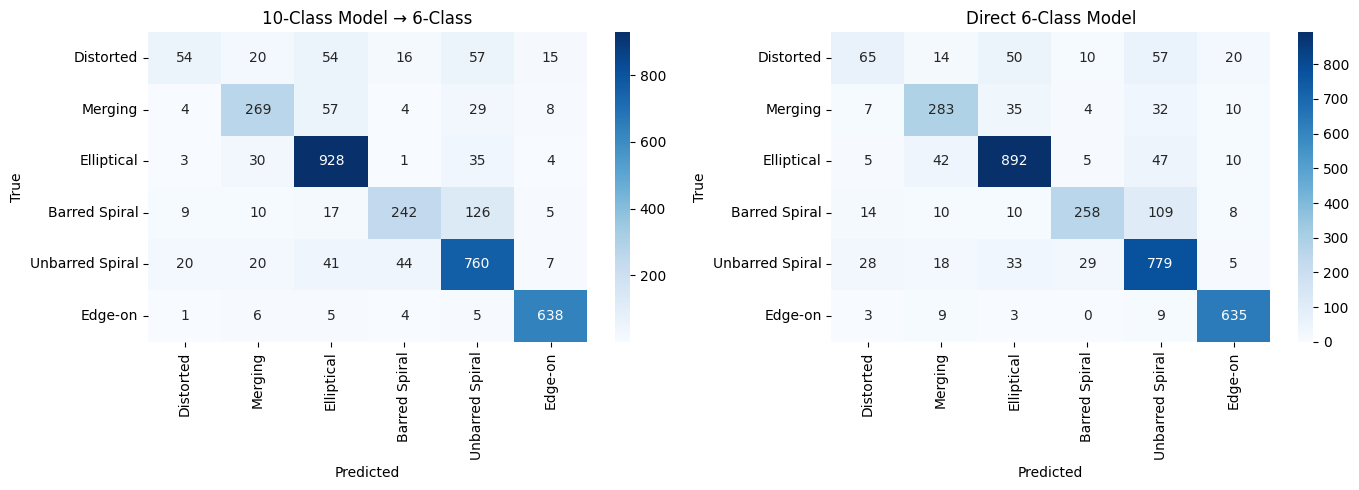

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    "Distorted",
    "Merging",
    "Elliptical",
    "Barred Spiral",
    "Unbarred Spiral",
    "Edge-on"
]

cm_10_as_6 = confusion_matrix(y_val, pred_10_as_6)
cm_6 = confusion_matrix(y_val, pred_6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_10_as_6,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("10-Class Model → 6-Class")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_6,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("Direct 6-Class Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.savefig('/content/drive/MyDrive/Astro Projects/Galaxy morphology/comparision visual/6_class_model_vs_10_class_model.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()